# 08. SHAP Values: Intuition, Computation, and Failure Modes

The previous notebook studied **permutation importance** and model reliance: how much a model's held-out performance deteriorates when feature information is disrupted. That was a global diagnostic.

This notebook moves to **SHAP values**, a local attribution method based on Shapley values from cooperative game theory. The central question changes from:

> How much does the model rely on this feature overall?

into:

> For this individual prediction, how much did each feature move the model output away from a baseline?

The decision-science framing is important. SHAP values can be useful for model debugging, stakeholder communication, and audit trails. But they are not automatic causal explanations, not policy recommendations, and not immune to baseline, correlation, and model-specification choices.

We will compute SHAP-style values from first principles rather than depending on the `shap` package. That makes the estimand visible and keeps the notebook executable in this environment.


## Learning Objectives

By the end of this notebook, you should be able to:

1. Define a SHAP value as a Shapley-weighted average marginal contribution.
2. Explain the additive decomposition

$$
f(x) = \phi_0 + \sum_{j=1}^{p}\phi_j(x)
$$

for a chosen model output and a chosen background distribution.
3. Compute exact interventional SHAP-style values for a small tabular model.
4. Read local waterfall explanations and global mean-absolute SHAP summaries.
5. Explain why SHAP values depend on the baseline, feature dependence assumptions, and output scale.
6. Use Monte Carlo Shapley sampling when exact enumeration is too expensive.
7. Translate SHAP outputs into a cautious decision-science report.


## 1. The Shapley Attribution Idea

Suppose a fitted model produces a score $f(x)$ for one account $x$. We want to distribute the difference between this score and a baseline score across the features.

For a feature set $F = \{1,\dots,p\}$, define a value function $v_x(S)$ for a subset of features $S \subseteq F$. In model explanation, $v_x(S)$ means:

> the expected model output when the features in $S$ are fixed to the account's observed values and the remaining features are filled in from a background distribution.

A common interventional version is

$$
v_x(S) = \mathbb{E}_{X_{-S}}\left[f(x_S, X_{-S})\right].
$$

Then the Shapley value for feature $j$ is

$$
\phi_j(x)
= \sum_{S \subseteq F\setminus\{j\}}
\frac{|S|!(p-|S|-1)!}{p!}
\left[v_x(S \cup \{j\}) - v_x(S)\right].
$$

This averages the marginal contribution of feature $j$ over every possible order in which features could enter the explanation.

The baseline term is

$$
\phi_0 = v_x(\varnothing),
$$

and the full coalition is

$$
v_x(F) = f(x).
$$

So the exact Shapley decomposition satisfies

$$
f(x) = \phi_0 + \sum_{j=1}^{p}\phi_j(x).
$$

Lundberg and Lee (2017) popularized SHAP as an additive feature attribution framework for model explanations. Later work developed efficient exact algorithms for tree ensembles and interaction values (Lundberg et al., 2020), while dependence-aware variants study what happens when features are correlated (Aas et al., 2021; Sellereite & Jullum, 2019).


## 2. What SHAP Explains, And What It Does Not

| Object | SHAP answers | SHAP does not answer |
|---|---|---|
| A fitted model | Which feature values moved this model's output from a baseline for this row? | Whether the feature caused the outcome |
| A chosen output scale | Contributions on probability, log-odds, dollars, minutes, or another scale | A universal importance independent of scale |
| A chosen background distribution | Contributions relative to a reference population | Contributions relative to every possible business baseline |
| A feature representation | Attribution to columns supplied to the model | Attribution to latent concepts not measured in the data |
| A local prediction | Why this prediction is high or low relative to baseline | Whether the recommended action is optimal or ethical |

That last distinction is the one that keeps the method professionally honest. A SHAP value can say that recent incidents moved a renewal-risk score upward. It cannot say that reducing incidents by one would reduce renewal risk by the same amount.


In [1]:
# Section focus: 2. What SHAP Explains, And What It Does Not.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

from itertools import combinations
from math import factorial
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

RANDOM_SEED = 2042
rng = np.random.default_rng(RANDOM_SEED)

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)

def smart_display(df, precision=3, max_width='360px'):
    """Display a table with wrapped text for cleaner rendered notebook output.
    
    Parameters
    ----------
    obj : object
        Data frame, series, or displayable object that should be shown in the notebook.
    max_width : object
        Maximum text width used before long table entries wrap across lines.
    max_rows : object
        Maximum number of rows shown when the object is a data frame.
    
    Returns
    -------
    object
        Display handle or formatted notebook output created from the supplied object.
    """
    if not isinstance(df, pd.DataFrame):
        display(df)
        return
    styler = df.style.set_table_styles(
        [{'selector': 'th', 'props': [('white-space', 'normal'), ('text-align', 'left')]}]
    ).set_properties(**{
        'white-space': 'normal',
        'max-width': max_width,
        'text-align': 'left',
        'vertical-align': 'top',
    })
    display(styler.format(precision=precision))


This result is an interpretation diagnostic. For What SHAP Explains, And What It Does Not, look at whether the explanation is stable, plausible, and useful for stakeholder review. The report should use fragile explanations carefully and show the reader where they move.


## 3. Synthetic Decision Case: Renewal-Risk Escalation

We will reuse the decision-science style from the previous notebooks. A customer-success team uses a model to prioritize accounts for renewal-risk review. The decision is operational because the model output affects which accounts receive scarce specialist attention.

The data intentionally include two features that are strongly related:

| Feature relationship | Why it matters for SHAP |
|---|---|
| `adoption_gap` and `training_gap` both measure account maturity | SHAP credit may be split across correlated maturity signals |
| `support_tickets_30d` and `recent_incidents_90d` both measure support burden | Attribution depends on whether missing features are treated independently or conditionally |
| `executive_sponsor` is protective but correlated with account size | A negative SHAP value can be a model explanation, not a causal effect of assigning a sponsor |
| `random_noise_feature` is unrelated to the outcome | A useful sanity check: it should have small attribution on average |

The model will be trained on six operational predictors plus a noise column. The generated data include extra business context, but the explanation model is intentionally kept small enough for exact Shapley enumeration.


In [2]:
# Section focus: 3. Synthetic Decision Case: Renewal-Risk Escalation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(z):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    z : object
        Linear predictor or standardized score being transformed by this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-z))


def make_renewal_data(n=5200, seed=2042):
    """Construct the renewal data helper used in the 08. SHAP Values: Intuition, Computation, and Failure Modes workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    account_size = rng.normal(0, 1, n)
    international_region = rng.binomial(1, 0.28, n)
    enterprise_segment = rng.binomial(1, sigmoid(-0.35 + 0.95 * account_size), n)

    maturity = rng.normal(0, 1, n) + 0.35 * enterprise_segment - 0.18 * international_region
    adoption_score = np.clip(sigmoid(0.55 * maturity + rng.normal(0, 0.65, n)), 0.02, 0.98)
    training_completion = np.clip(sigmoid(0.70 * maturity + rng.normal(0, 0.58, n)), 0.02, 0.98)

    adoption_gap = 1 - adoption_score
    training_gap = 1 - training_completion

    support_intensity = np.exp(0.45 + 0.95 * adoption_gap + 0.25 * international_region + rng.normal(0, 0.18, n))
    support_tickets_30d = rng.poisson(support_intensity)
    recent_incidents_90d = rng.poisson(np.exp(-1.10 + 0.34 * support_tickets_30d + 0.65 * training_gap))
    recent_incidents_90d = np.clip(recent_incidents_90d, 0, 8)

    billing_delay_days = np.clip(rng.gamma(shape=1.45, scale=2.1, size=n) + 1.25 * international_region + 0.55 * adoption_gap, 0, 18)
    contract_value_log = 10.1 + 0.55 * account_size + 0.45 * enterprise_segment + rng.normal(0, 0.28, n)
    executive_sponsor = rng.binomial(1, sigmoid(-0.65 + 0.70 * enterprise_segment + 0.42 * account_size - 0.45 * adoption_gap), n)
    random_noise_feature = rng.normal(0, 1, n)

    logit = (
        -4.75
        + 2.45 * adoption_gap
        + 1.05 * training_gap
        + 0.21 * support_tickets_30d
        + 0.58 * recent_incidents_90d
        + 0.10 * billing_delay_days
        - 0.62 * executive_sponsor
        + 0.18 * international_region
        + 0.35 * adoption_gap * np.log1p(support_tickets_30d)
        - 0.10 * (contract_value_log - 10.1)
        + rng.normal(0, 0.22, n)
    )
    renewal_risk_probability = sigmoid(logit)
    renewal_risk = rng.binomial(1, renewal_risk_probability)

    return pd.DataFrame(
        {
            'adoption_gap': adoption_gap,
            'training_gap': training_gap,
            'support_tickets_30d': support_tickets_30d,
            'recent_incidents_90d': recent_incidents_90d,
            'billing_delay_days': billing_delay_days,
            'contract_value_log': contract_value_log,
            'executive_sponsor': executive_sponsor,
            'international_region': international_region,
            'random_noise_feature': random_noise_feature,
            'renewal_risk': renewal_risk,
        }
    )

FEATURES = [
    'adoption_gap',
    'training_gap',
    'support_tickets_30d',
    'recent_incidents_90d',
    'billing_delay_days',
    'executive_sponsor',
    'random_noise_feature',
]
TARGET = 'renewal_risk'

FEATURE_LABELS = {
    'adoption_gap': 'Adoption gap',
    'training_gap': 'Training gap',
    'support_tickets_30d': 'Support tickets in last 30 days',
    'recent_incidents_90d': 'Recent incidents in last 90 days',
    'billing_delay_days': 'Billing delay days',
    'contract_value_log': 'Log contract value',
    'executive_sponsor': 'Executive sponsor present',
    'international_region': 'International region',
    'random_noise_feature': 'Random noise feature',
}

df = make_renewal_data()
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_SEED,
)

summary = pd.DataFrame(
    [
        {'quantity': 'Rows', 'value': len(df)},
        {'quantity': 'Train rows', 'value': len(X_train)},
        {'quantity': 'Test rows', 'value': len(X_test)},
        {'quantity': 'Renewal-risk rate', 'value': y.mean()},
        {'quantity': 'Correlation: adoption gap and training gap', 'value': df[['adoption_gap', 'training_gap']].corr().iloc[0, 1]},
        {'quantity': 'Correlation: tickets and incidents', 'value': df[['support_tickets_30d', 'recent_incidents_90d']].corr().iloc[0, 1]},
    ]
)

smart_display(summary.round(3))
smart_display(df[FEATURES + [TARGET]].head(6).round(3))


,quantity,value
0,Rows,5200.000
1,Train rows,3640.000
2,Test rows,1560.000
3,Renewal-risk rate,0.285
4,Correlation: adoption gap and training gap,0.510
5,Correlation: tickets and incidents,0.653


,adoption_gap,training_gap,support_tickets_30d,recent_incidents_90d,billing_delay_days,executive_sponsor,random_noise_feature,renewal_risk
0,0.466,0.601,0,0,0.722,1,-0.501,0
1,0.510,0.331,4,2,4.875,0,-0.161,0
2,0.647,0.804,3,2,1.842,1,0.177,1
3,0.625,0.746,3,1,5.541,0,-0.965,1
4,0.727,0.740,7,4,4.930,0,-1.403,1
5,0.222,0.247,3,2,2.236,0,0.507,0


Synthetic Decision Case: Renewal-Risk Escalation is useful only if the explanation remains credible under reasonable modeling choices.


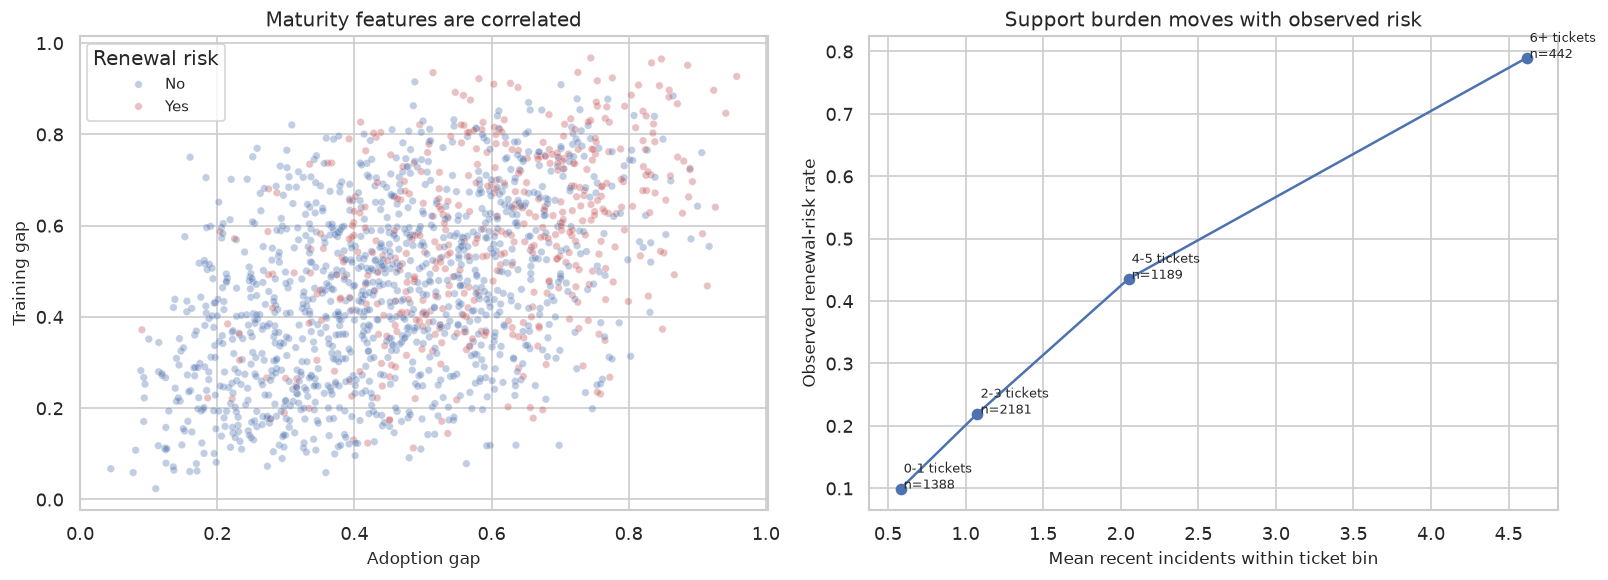

In [3]:
# Section focus: 3. Synthetic Decision Case: Renewal-Risk Escalation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.0))

plot_sample = df.sample(1600, random_state=RANDOM_SEED).copy()
plot_sample['renewal_risk_label'] = np.where(plot_sample['renewal_risk'].eq(1), 'Yes', 'No')

sns.scatterplot(
    data=plot_sample,
    x='adoption_gap',
    y='training_gap',
    hue='renewal_risk_label',
    hue_order=['No', 'Yes'],
    palette={'No': '#4c72b0', 'Yes': '#c44e52'},
    alpha=0.35,
    s=20,
    ax=axes[0],
)
axes[0].set_title('Maturity features are correlated')
axes[0].set_xlabel('Adoption gap')
axes[0].set_ylabel('Training gap')
axes[0].legend(title='Renewal risk', loc='upper left')

ticket_bins = pd.cut(df['support_tickets_30d'], bins=[-0.1, 1, 3, 5, 20], labels=['0-1 tickets', '2-3 tickets', '4-5 tickets', '6+ tickets'])
burden_summary = (
    df.assign(ticket_bin=ticket_bins)
    .groupby('ticket_bin', observed=True)
    .agg(
        observed_risk_rate=(TARGET, 'mean'),
        mean_incidents=('recent_incidents_90d', 'mean'),
        rows=(TARGET, 'size'),
    )
    .reset_index()
)
axes[1].plot(burden_summary['mean_incidents'], burden_summary['observed_risk_rate'], marker='o', color='#4c72b0')
for _, row in burden_summary.iterrows():
    axes[1].text(row['mean_incidents'] + 0.02, row['observed_risk_rate'], f"{row['ticket_bin']}\nn={int(row['rows'])}", fontsize=8)
axes[1].set_title('Support burden moves with observed risk')
axes[1].set_xlabel('Mean recent incidents within ticket bin')
axes[1].set_ylabel('Observed renewal-risk rate')
plt.tight_layout()
plt.show()


In Synthetic Decision Case: Renewal-Risk Escalation, the explanation should help a reviewer understand what is stable, what is fragile, and what still needs checking. The analyst should flag this movement before the explanation supports a decision.


### Discussion of the Data Design

The data are built so that a good model can discover meaningful prediction structure. But the correlated variables create the exact attribution problem that SHAP users face in practice.

If an account has low adoption and low training completion, how much credit should each variable receive? If incidents and tickets move together, should the explanation blame incidents, tickets, or the broader support-burden construct? SHAP values answer only after we define a value function and a background distribution.

The simulated renewal-risk setting gives SHAP something realistic to wrestle with. The model sees correlated maturity signals, correlated burden signals, and nonlinear risk regions. That means a good prediction can be made for reasons that are distributed across several related variables rather than isolated in one clean driver.

The experiment is therefore about attribution under dependence. We know the variables were generated from related operating states, so we can ask whether SHAP explanations are stable, whether they split credit in an intuitive way, and where a local explanation might be over-read by a stakeholder.


## 4. Fit Prediction Models

We will fit three models:

| Model | Role in the notebook |
|---|---|
| Logistic regression | Transparent reference model |
| Random forest | Nonlinear model with feature subsampling |
| Histogram gradient boosting | Main black-box model for SHAP-style explanations |

The SHAP computations below will focus on the gradient boosting model because that is the type of model for which post-hoc explanations are often requested in industry workflows.


In [4]:
# Section focus: 4. Fit Prediction Models.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def predict_risk(model, X_input):
    """Carry out the predict risk step used in the 08. SHAP Values: Intuition, Computation, and Failure Modes workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X_input : object
        Feature row, feature matrix, or covariate value passed into the model workflow.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the predict risk calculation.
    """
    return model.predict_proba(X_input)[:, 1]

scaled_logit = Pipeline(
    steps=[
        ('scale', StandardScaler()),
        ('model', LogisticRegression(max_iter=800, C=0.8, random_state=RANDOM_SEED)),
    ]
)

rf_model = RandomForestClassifier(
    n_estimators=240,
    min_samples_leaf=35,
    max_features='sqrt',
    random_state=RANDOM_SEED,
    n_jobs=1,
)

gbm_model = HistGradientBoostingClassifier(
    max_iter=220,
    learning_rate=0.045,
    max_leaf_nodes=24,
    min_samples_leaf=45,
    l2_regularization=0.025,
    random_state=RANDOM_SEED,
)

models = {
    'Logistic regression': scaled_logit,
    'Random forest': rf_model,
    'Gradient boosting': gbm_model,
}

metric_rows = []
for model_name, model in models.items():
    model.fit(X_train, y_train)
    pred = predict_risk(model, X_test)
    metric_rows.append(
        {
            'model': model_name,
            'roc_auc': roc_auc_score(y_test, pred),
            'average_precision': average_precision_score(y_test, pred),
            'brier_score': brier_score_loss(y_test, pred),
            'log_loss': log_loss(y_test, pred),
            'mean_predicted_risk': pred.mean(),
        }
    )

metrics = pd.DataFrame(metric_rows).sort_values('roc_auc', ascending=False)
smart_display(metrics.round(3))


,model,roc_auc,average_precision,brier_score,log_loss,mean_predicted_risk
0,Logistic regression,0.843,0.738,0.133,0.417,0.289
1,Random forest,0.841,0.726,0.136,0.428,0.288
2,Gradient boosting,0.831,0.719,0.139,0.438,0.283


This result is an interpretation diagnostic. For Fit Prediction Models, look at whether the explanation is stable, plausible, and useful for stakeholder review. A dependable explanation should survive reasonable changes in settings.


### Discussion of Baseline Performance

The models perform well enough that explanations are meaningful. This matters. Explaining a poor model can create a false sense of analytical depth. A model should first clear basic predictive, calibration, and operational checks before its explanations are used in decision conversations.

Notice also that SHAP values will explain the **chosen fitted model**, not the data-generating process. If the random forest and gradient boosting model learn different patterns, their explanations may differ even on the same account.


## 5. Exact Interventional SHAP From First Principles

We now implement the exact Shapley formula for a small number of features. The function below uses a background sample from the training data.

For a subset $S$, we evaluate the model on rows where:

- features in $S$ are fixed to the account being explained;
- features outside $S$ come from background accounts;
- the value $v_x(S)$ is the average predicted risk over those hybrid rows.

This is an **interventional** value function because it breaks feature dependence when missing features are drawn independently from the background. That is common, useful, and sometimes misleading.


In [5]:
# Section focus: 5. Exact Interventional SHAP From First Principles.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def all_subsets(indices):
    """Carry out the all subsets step used in the 08. SHAP Values: Intuition, Computation, and Failure Modes workflow.
    
    Parameters
    ----------
    indices : object
        The indices setting that controls the all subsets calculation in this notebook.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    indices = list(indices)
    for r in range(len(indices) + 1):
        yield from combinations(indices, r)


def exact_interventional_shap(model, x_row, background, feature_names, output_name='risk'):
    """Compute exact interventional Shapley attributions from a background data set.
    
    Parameters
    ----------
    model : object
        Prediction model whose output is decomposed into feature attributions.
    x_row : object
        Single focal observation whose prediction is being explained.
    background : object
        Background feature table used to marginalize features that are outside each coalition.
    feature_names : object
        Names of the features included in the Shapley decomposition.
    
    Returns
    -------
    object
        pandas.DataFrame containing one attribution row per feature for the focal observation.
    """
    feature_names = list(feature_names)
    p = len(feature_names)
    bg = background[feature_names].reset_index(drop=True).copy()
    x_values = x_row[feature_names]
    indices = tuple(range(p))

    @lru_cache(maxsize=None)
    def value(subset):
        """Carry out the value step used in the 08. SHAP Values: Intuition, Computation, and Failure Modes workflow.
        
        Parameters
        ----------
        subset : object
            The subset setting that controls the value calculation in this notebook.
        
        Returns
        -------
        object
            Intermediate result produced by the value calculation and reused by later cells.
        """
        subset = tuple(sorted(subset))
        X_eval = bg.copy()
        for idx in subset:
            X_eval[feature_names[idx]] = x_values.iloc[idx]
        return float(predict_risk(model, X_eval).mean())

    phi = np.zeros(p)
    for j in indices:
        others = [idx for idx in indices if idx != j]
        for subset in all_subsets(others):
            subset = tuple(sorted(subset))
            weight = factorial(len(subset)) * factorial(p - len(subset) - 1) / factorial(p)
            with_j = tuple(sorted(subset + (j,)))
            phi[j] += weight * (value(with_j) - value(subset))

    base_value = value(tuple())
    full_value = value(indices)
    prediction = float(predict_risk(model, x_row[feature_names].to_frame().T)[0])

    result = pd.DataFrame(
        {
            'feature': feature_names,
            'feature_label': [FEATURE_LABELS[f] for f in feature_names],
            'feature_value': x_values.to_numpy(dtype=float),
            f'shap_{output_name}': phi,
            f'abs_shap_{output_name}': np.abs(phi),
        }
    ).sort_values(f'abs_shap_{output_name}', ascending=False)

    check = {
        'base_value': base_value,
        'sum_shap_values': float(phi.sum()),
        'base_plus_sum': float(base_value + phi.sum()),
        'full_coalition_value': full_value,
        'model_prediction': prediction,
        'additivity_error': float((base_value + phi.sum()) - prediction),
    }
    return result, check

background = X_train.sample(90, random_state=RANDOM_SEED)
test_predictions = pd.Series(predict_risk(gbm_model, X_test), index=X_test.index, name='predicted_risk')

high_risk_index = test_predictions.sort_values(ascending=False).index[12]
moderate_risk_index = test_predictions.sub(test_predictions.median()).abs().sort_values().index[0]
low_risk_index = test_predictions.sort_values().index[12]

explain_indices = {
    'High-risk account': high_risk_index,
    'Typical account': moderate_risk_index,
    'Low-risk account': low_risk_index,
}

local_explanations = {}
local_checks = []
for label, idx in explain_indices.items():
    explanation, check = exact_interventional_shap(gbm_model, X_test.loc[idx], background, FEATURES, output_name='risk')
    explanation['account_type'] = label
    local_explanations[label] = explanation
    check['account_type'] = label
    check['row_index'] = idx
    check['observed_outcome'] = int(y_test.loc[idx])
    local_checks.append(check)

check_table = pd.DataFrame(local_checks)[
    ['account_type', 'row_index', 'observed_outcome', 'base_value', 'sum_shap_values', 'base_plus_sum', 'model_prediction', 'additivity_error']
]
smart_display(check_table.round(5))


,account_type,row_index,observed_outcome,base_value,sum_shap_values,base_plus_sum,model_prediction,additivity_error
0,High-risk account,4325,1,0.308,0.677,0.985,0.985,-0.000
1,Typical account,3441,1,0.308,-0.140,0.169,0.169,0.000
2,Low-risk account,501,0,0.308,-0.302,0.007,0.007,0.000


For Exact Interventional SHAP From First Principles, the right question is whether this explanation can survive baseline, sample, or neighborhood changes.


### Discussion of Additivity

The additivity check is the first thing to verify in any SHAP workflow. The model prediction should equal the baseline plus the sum of feature attributions, up to numerical error.

The equality is not magic. It follows from the value function we chose. If we change the output scale, background data, or dependence assumption, we change the decomposition.


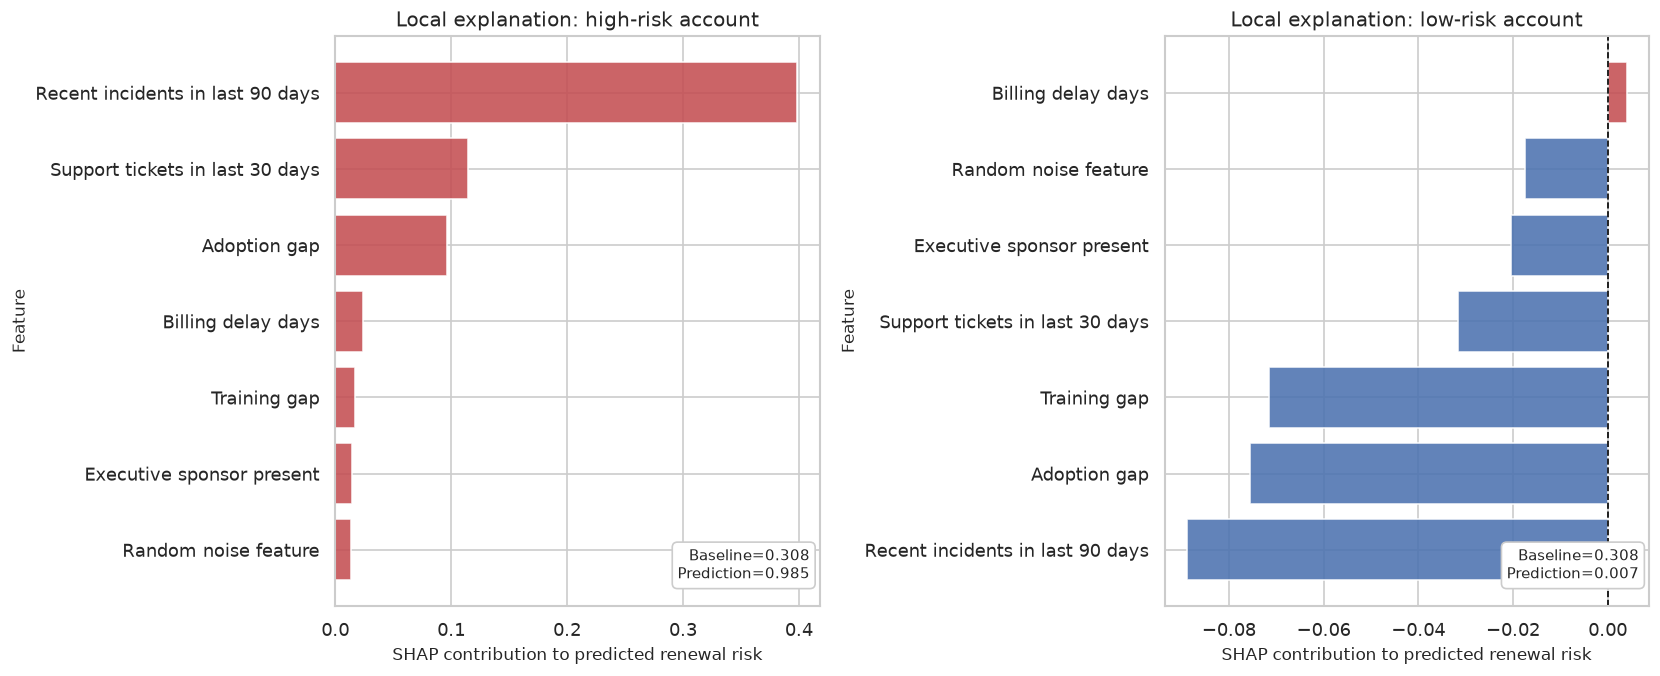

,feature_label,feature_value,shap_risk
3,Recent incidents in last 90 days,8.000,0.398
2,Support tickets in last 30 days,9.000,0.114
0,Adoption gap,0.828,0.096
4,Billing delay days,4.072,0.024
1,Training gap,0.501,0.017
5,Executive sponsor present,0.000,0.014
6,Random noise feature,-1.250,0.013


In [6]:
# Section focus: Discussion of Additivity.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def plot_local_shap_bar(explanation, check, title, ax=None):
    """Draw the local shap bar figure for the 08. SHAP Values: Intuition, Computation, and Failure Modes analysis.
    
    Parameters
    ----------
    explanation : object
        The explanation setting that controls the local shap bar calculation in this notebook.
    check : object
        The check setting that controls the local shap bar calculation in this notebook.
    title : object
        Title used to label the displayed result.
    ax : object
        Matplotlib axis on which the plot is drawn.
    
    Returns
    -------
    object
        Matplotlib figure or axis object containing the visual diagnostic.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9.8, 5.6))
    plot_df = explanation.sort_values('shap_risk', ascending=True).copy()
    colors = np.where(plot_df['shap_risk'] >= 0, '#c44e52', '#4c72b0')
    ax.barh(plot_df['feature_label'], plot_df['shap_risk'], color=colors, alpha=0.88)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel('SHAP contribution to predicted renewal risk')
    ax.set_ylabel('Feature')
    ax.text(
        0.98,
        0.04,
        f"Baseline={check['base_value']:.3f}\nPrediction={check['model_prediction']:.3f}",
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        bbox={'boxstyle': 'round,pad=0.35', 'facecolor': 'white', 'edgecolor': '#cccccc'},
        fontsize=9,
    )
    return ax

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.8))
plot_local_shap_bar(local_explanations['High-risk account'], dict(check_table.set_index('account_type').loc['High-risk account']), 'Local explanation: high-risk account', ax=axes[0])
plot_local_shap_bar(local_explanations['Low-risk account'], dict(check_table.set_index('account_type').loc['Low-risk account']), 'Local explanation: low-risk account', ax=axes[1])
plt.tight_layout()
plt.show()

smart_display(local_explanations['High-risk account'][['feature_label', 'feature_value', 'shap_risk']].round(4))


Read Discussion of Additivity as a communication test. The explanation is useful when a reviewer can challenge it and still see a stable story.


### Discussion of the Local Explanations

A positive SHAP value pushes the account's predicted risk above the background baseline. A negative SHAP value pushes it below the baseline. In this example, the high-risk account is typically pushed upward by maturity gaps and support burden, while protective or lower-risk signals can pull downward.

This is a **local model explanation**. If `support_tickets_30d` has a positive value for this account, the correct sentence is:

> Relative to the background accounts, this account's ticket burden increased the fitted model's predicted risk.

The incorrect sentence is:

> Tickets caused the account to churn, and reducing tickets by this amount would reduce risk by the SHAP value.

That causal statement requires a causal design as well as a prediction explanation.


## 6. Global SHAP Summaries From Local Explanations

SHAP is local by construction, but analysts often aggregate local values into global summaries. The common global statistic is

$$
\mathbb{E}_{i}\left[|\phi_j(x_i)|\right],
$$

which measures the average absolute contribution of feature $j$ over a set of observations.

This is not the same estimand as permutation importance. Mean absolute SHAP summarizes local attribution magnitude; permutation importance summarizes performance deterioration after feature disruption.


In [7]:
# Section focus: 6. Global SHAP Summaries From Local Explanations.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

GLOBAL_EXPLANATION_ROWS = 28
global_sample = X_test.sample(GLOBAL_EXPLANATION_ROWS, random_state=RANDOM_SEED + 1)

shap_rows = []
for row_number, (idx, x_row) in enumerate(global_sample.iterrows()):
    explanation, check = exact_interventional_shap(gbm_model, x_row, background, FEATURES, output_name='risk')
    for _, row in explanation.iterrows():
        shap_rows.append(
            {
                'row_index': idx,
                'feature': row['feature'],
                'feature_label': row['feature_label'],
                'feature_value': row['feature_value'],
                'shap_risk': row['shap_risk'],
                'abs_shap_risk': abs(row['shap_risk']),
                'prediction': check['model_prediction'],
                'observed_outcome': int(y_test.loc[idx]),
            }
        )

global_shap = pd.DataFrame(shap_rows)
global_summary = (
    global_shap.groupby(['feature', 'feature_label'], as_index=False)
    .agg(
        mean_abs_shap=('abs_shap_risk', 'mean'),
        mean_shap=('shap_risk', 'mean'),
        p05=('shap_risk', lambda x: np.quantile(x, 0.05)),
        p95=('shap_risk', lambda x: np.quantile(x, 0.95)),
    )
    .sort_values('mean_abs_shap', ascending=False)
)
smart_display(global_summary.round(4))


,feature,feature_label,mean_abs_shap,mean_shap,p05,p95
4,recent_incidents_90d,Recent incidents in last 90 days,0.169,0.055,-0.138,0.391
0,adoption_gap,Adoption gap,0.077,0.012,-0.109,0.182
5,support_tickets_30d,Support tickets in last 30 days,0.064,0.007,-0.083,0.142
6,training_gap,Training gap,0.034,-0.002,-0.059,0.049
2,executive_sponsor,Executive sponsor present,0.030,0.006,-0.046,0.044
1,billing_delay_days,Billing delay days,0.028,-0.008,-0.054,0.048
3,random_noise_feature,Random noise feature,0.021,-0.007,-0.034,0.039


Read Global SHAP Summaries From Local Explanations as a stress test for the explanation. Stable reasons strengthen the story; shifting local reasons should stay in the caveats.


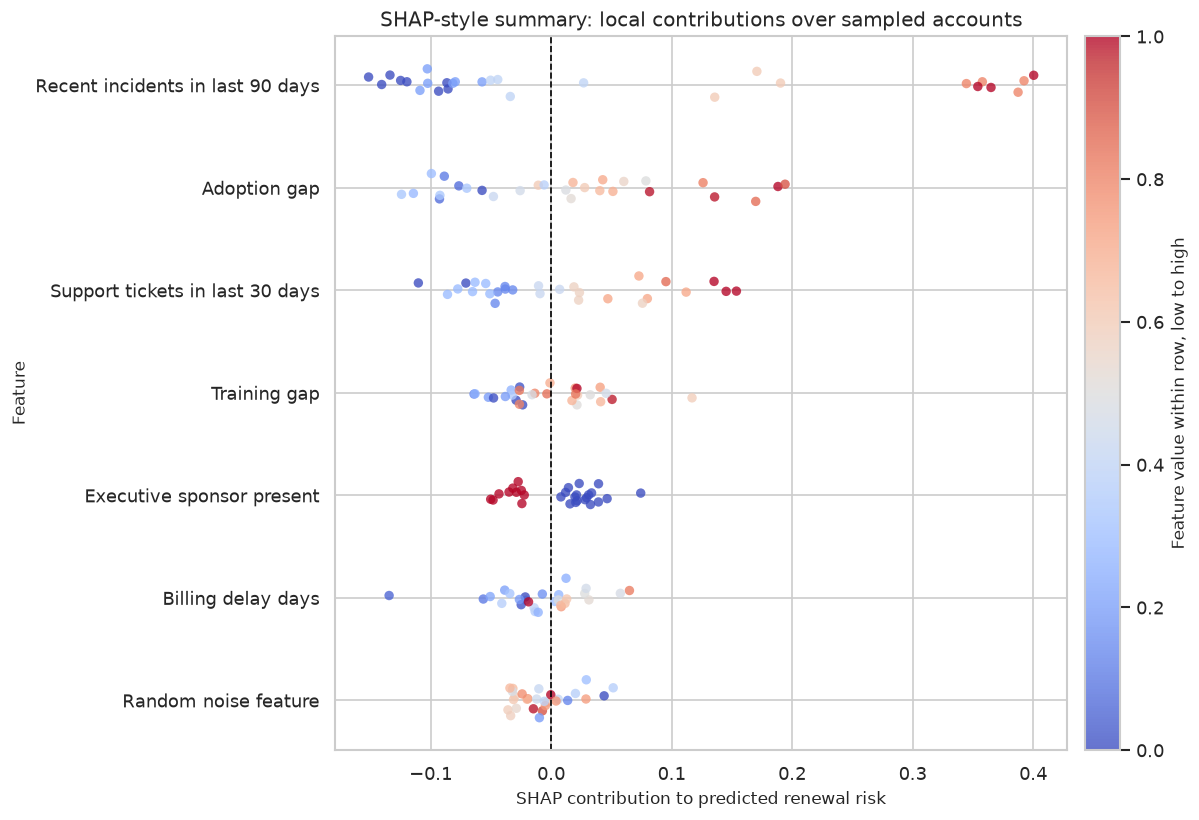

In [8]:
# Section focus: 6. Global SHAP Summaries From Local Explanations.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

feature_order = global_summary['feature'].tolist()[::-1]
feature_to_y = {feature: pos for pos, feature in enumerate(feature_order)}
plot_shap = global_shap.copy()
plot_shap['y_position'] = plot_shap['feature'].map(feature_to_y)

# Standardize feature values only for coloring inside each feature row.
plot_shap['feature_value_scaled'] = plot_shap.groupby('feature')['feature_value'].transform(
    lambda s: (s - s.min()) / (s.max() - s.min() + 1e-12)
)
plot_shap['jitter'] = rng.normal(0, 0.07, size=len(plot_shap))

fig, ax = plt.subplots(figsize=(10.4, 7.0))
scatter = ax.scatter(
    plot_shap['shap_risk'],
    plot_shap['y_position'] + plot_shap['jitter'],
    c=plot_shap['feature_value_scaled'],
    cmap='coolwarm',
    alpha=0.78,
    s=32,
    edgecolor='none',
)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(range(len(feature_order)))
ax.set_yticklabels([FEATURE_LABELS[f] for f in feature_order])
ax.set_title('SHAP-style summary: local contributions over sampled accounts')
ax.set_xlabel('SHAP contribution to predicted renewal risk')
ax.set_ylabel('Feature')
cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Feature value within row, low to high')
plt.tight_layout()
plt.show()


Use the explanation as a stress test of the model narrative. In Global SHAP Summaries From Local Explanations, the displayed reasons should make sense with the data-generating story and the operating decision. Conflicting explanation views should lower the confidence of the story presented to stakeholders.


### Discussion of the SHAP Summary Plot

Each dot is a local attribution for one account-feature pair. The horizontal position is the SHAP contribution. The color shows whether that feature's value is low or high relative to the sampled accounts.

This plot is richer than a bar chart because it shows direction and heterogeneity. For example, a feature can have a large mean absolute SHAP value because it pushes some accounts upward and others downward. A bar chart would hide that.

But the plot is still not causal. It displays how the fitted model uses feature values relative to the background sample.


## 7. SHAP Versus Permutation Importance

Permutation importance and mean absolute SHAP are often placed side by side, but they answer different questions.

| Method | Question | Unit |
|---|---|---|
| Mean absolute SHAP | How large are this feature's local contributions on average? | Model-output units |
| Permutation importance | How much does held-out performance deteriorate when this feature is disrupted? | Metric units |

They should usually agree on the broad signals when a model has stable reliance. They need not agree exactly.


In [9]:
# Section focus: 7. SHAP Versus Permutation Importance.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def evaluate_score(model, X_input, y_input, metric='roc_auc'):
    """Evaluate score for the 08. SHAP Values: Intuition, Computation, and Failure Modes decision workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X_input : object
        Feature row, feature matrix, or covariate value passed into the model workflow.
    y_input : object
        The y input setting that controls the score calculation in this notebook.
    metric : object
        Metric name or metric value used to score model or decision behavior.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the score calculation.
    """
    pred = predict_risk(model, X_input)
    if metric == 'roc_auc':
        return roc_auc_score(y_input, pred)
    if metric == 'average_precision':
        return average_precision_score(y_input, pred)
    raise ValueError(f'Unsupported metric: {metric}')


def repeated_permutation_importance_score(model, X_input, y_input, features, metric='roc_auc', n_repeats=24, seed=2047):
    """Carry out the repeated permutation importance score step used in the 08. SHAP Values: Intuition, Computation, and Failure Modes workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X_input : object
        Feature row, feature matrix, or covariate value passed into the model workflow.
    y_input : object
        The y input setting that controls the repeated permutation importance score calculation in this notebook.
    features : object
        Feature column names or feature matrix used by the model.
    metric : object
        Metric name or metric value used to score model or decision behavior.
    n_repeats : object
        Count or size setting for the repeated permutation importance score calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng_local = np.random.default_rng(seed)
    baseline = evaluate_score(model, X_input, y_input, metric=metric)
    rows = []
    X_base = X_input.reset_index(drop=True)
    y_base = pd.Series(y_input).reset_index(drop=True)

    for feature in features:
        for repeat in range(n_repeats):
            X_perm = X_base.copy()
            X_perm[feature] = rng_local.permutation(X_perm[feature].to_numpy())
            permuted_score = evaluate_score(model, X_perm, y_base, metric=metric)
            rows.append(
                {
                    'feature': feature,
                    'feature_label': FEATURE_LABELS[feature],
                    'repeat': repeat,
                    'metric': metric,
                    'score_drop': baseline - permuted_score,
                }
            )
    return pd.DataFrame(rows)

permutation_df = repeated_permutation_importance_score(
    gbm_model,
    X_test,
    y_test,
    FEATURES,
    metric='roc_auc',
    n_repeats=24,
    seed=2047,
)
permutation_summary = (
    permutation_df.groupby(['feature', 'feature_label'], as_index=False)
    .agg(mean_auc_drop=('score_drop', 'mean'), sd_auc_drop=('score_drop', 'std'))
)

shap_vs_perm = global_summary[['feature', 'feature_label', 'mean_abs_shap']].merge(
    permutation_summary[['feature', 'mean_auc_drop']],
    on='feature',
    how='left',
).sort_values('mean_abs_shap', ascending=False)
shap_vs_perm['rank_by_abs_shap'] = shap_vs_perm['mean_abs_shap'].rank(ascending=False, method='min').astype(int)
shap_vs_perm['rank_by_permutation'] = shap_vs_perm['mean_auc_drop'].rank(ascending=False, method='min').astype(int)
smart_display(shap_vs_perm.round(4))


,feature,feature_label,mean_abs_shap,mean_auc_drop,rank_by_abs_shap,rank_by_permutation
0,recent_incidents_90d,Recent incidents in last 90 days,0.169,0.111,1,1
1,adoption_gap,Adoption gap,0.077,0.062,2,2
2,support_tickets_30d,Support tickets in last 30 days,0.064,0.021,3,3
3,training_gap,Training gap,0.034,0.016,4,4
4,executive_sponsor,Executive sponsor present,0.030,0.006,5,5
5,billing_delay_days,Billing delay days,0.028,0.005,6,6
6,random_noise_feature,Random noise feature,0.021,-0.002,7,7


This result is an interpretation diagnostic. For SHAP Versus Permutation Importance, look at whether the explanation is stable, plausible, and useful for stakeholder review. Treat this kind of movement as evidence about explanation reliability, not as a small formatting issue.


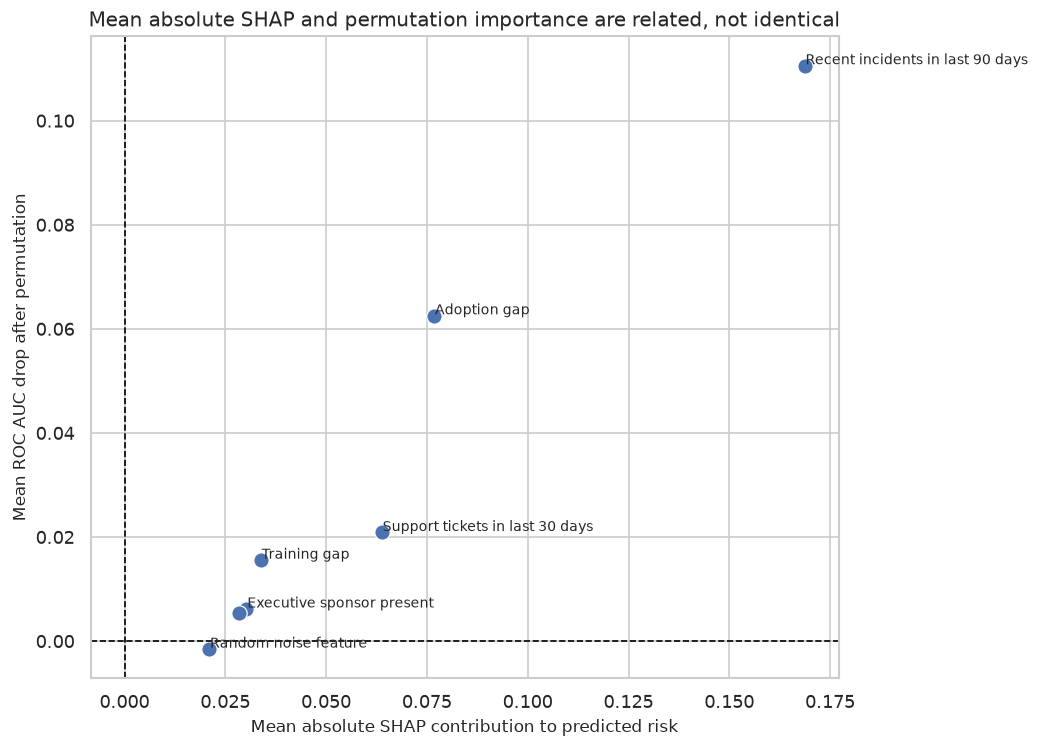

In [10]:
fig, ax = plt.subplots(figsize=(8.8, 6.4))
sns.scatterplot(
    data=shap_vs_perm,
    x='mean_abs_shap',
    y='mean_auc_drop',
    s=85,
    color='#4c72b0',
    ax=ax,
)
for _, row in shap_vs_perm.iterrows():
    if row['rank_by_abs_shap'] <= 5 or row['rank_by_permutation'] <= 5 or row['feature'] == 'random_noise_feature':
        ax.text(row['mean_abs_shap'] + 0.00025, row['mean_auc_drop'] + 0.00025, row['feature_label'], fontsize=8.5)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Mean absolute SHAP and permutation importance are related, not identical')
ax.set_xlabel('Mean absolute SHAP contribution to predicted risk')
ax.set_ylabel('Mean ROC AUC drop after permutation')
plt.tight_layout()
plt.show()


The explanation result should be compared with the decision story. In SHAP Versus Permutation Importance, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. Stakeholders act on the explanation, so clarity and stability are part of the technical result.


### Discussion of the Comparison

The comparison should be read as a diagnostic, not a contest. If a feature has high mean absolute SHAP and high permutation importance, the model uses it frequently and performance depends on it. If a feature has high SHAP but lower permutation importance, it may contribute locally while being partly redundant. If a feature has low SHAP and low permutation importance, it is probably not central to this fitted model.

The random noise feature should remain near the bottom. If it did not, the explanation workflow would deserve suspicion.


## 8. Baseline Sensitivity

SHAP values are contributions **relative to a baseline**. Changing the background population can change the story.

For example, a high-risk account can be compared to:

1. all training accounts;
2. low-risk-looking accounts with high adoption and few incidents;
3. high-burden accounts with many tickets or incidents.

The same account can receive different attributions under these baselines because the contrast class changed.


In [11]:
# Section focus: 8. Baseline Sensitivity.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

low_burden_background = X_train.loc[
    (X_train['adoption_gap'] <= X_train['adoption_gap'].quantile(0.35))
    & (X_train['support_tickets_30d'] <= X_train['support_tickets_30d'].quantile(0.45))
].sample(90, random_state=RANDOM_SEED + 2, replace=True)

high_burden_background = X_train.loc[
    (X_train['adoption_gap'] >= X_train['adoption_gap'].quantile(0.60))
    | (X_train['recent_incidents_90d'] >= X_train['recent_incidents_90d'].quantile(0.75))
].sample(90, random_state=RANDOM_SEED + 3, replace=True)

backgrounds = {
    'All training accounts': background,
    'Low-burden baseline': low_burden_background,
    'High-burden baseline': high_burden_background,
}

baseline_rows = []
baseline_explanations = []
x_focus = X_test.loc[high_risk_index]
for bg_name, bg_data in backgrounds.items():
    explanation, check = exact_interventional_shap(gbm_model, x_focus, bg_data, FEATURES, output_name='risk')
    baseline_rows.append(
        {
            'background': bg_name,
            'base_value': check['base_value'],
            'prediction': check['model_prediction'],
            'sum_shap_values': check['sum_shap_values'],
            'additivity_error': check['additivity_error'],
        }
    )
    tmp = explanation[['feature', 'feature_label', 'shap_risk']].copy()
    tmp['background'] = bg_name
    baseline_explanations.append(tmp)

baseline_table = pd.DataFrame(baseline_rows)
baseline_long = pd.concat(baseline_explanations, ignore_index=True)
smart_display(baseline_table.round(5))


,background,base_value,prediction,sum_shap_values,additivity_error
0,All training accounts,0.308,0.985,0.677,-0.000
1,Low-burden baseline,0.066,0.985,0.919,-0.000
2,High-burden baseline,0.439,0.985,0.546,-0.000


Baseline Sensitivity should make the model story easier to inspect instead of merely more polished.


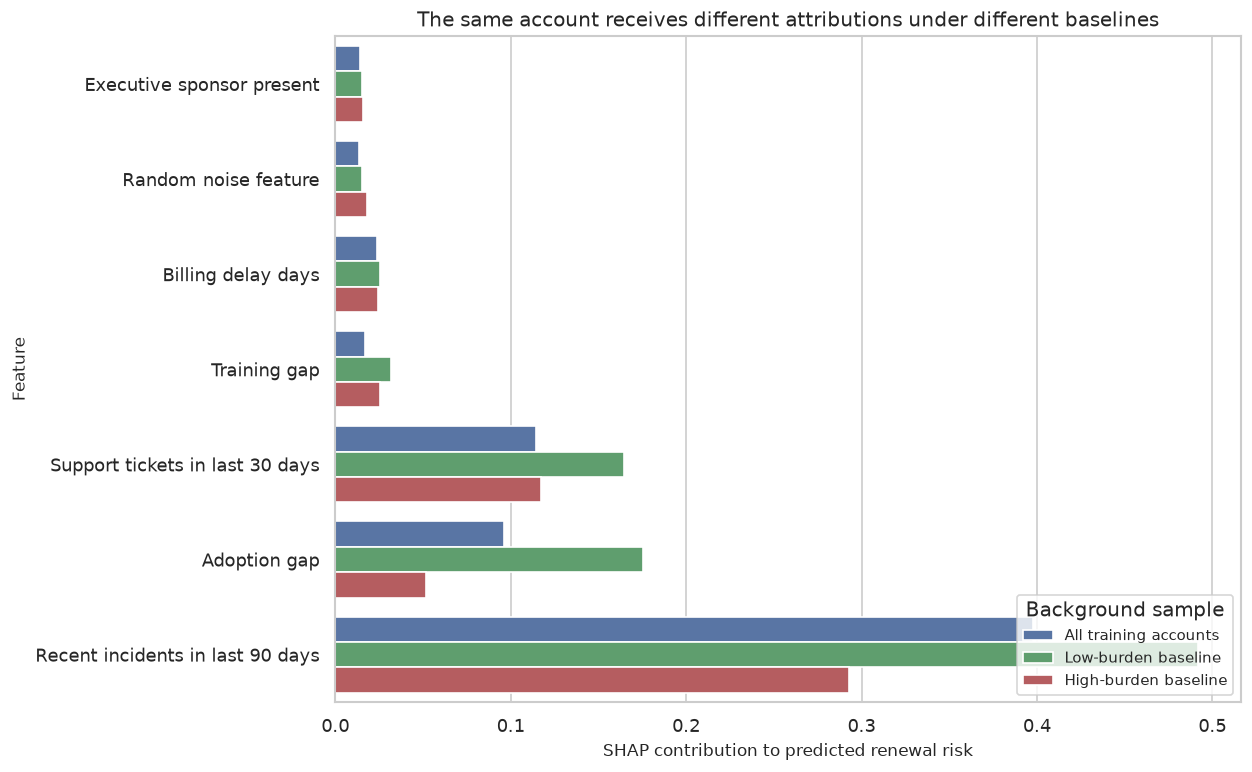

In [12]:
# Section focus: 8. Baseline Sensitivity.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

selected_features = (
    baseline_long.groupby(['feature', 'feature_label'])['shap_risk']
    .apply(lambda s: np.max(np.abs(s)))
    .sort_values(ascending=False)
    .head(7)
    .reset_index()['feature']
    .tolist()
)
plot_baseline = baseline_long.loc[baseline_long['feature'].isin(selected_features)].copy()
plot_baseline['feature_label'] = pd.Categorical(
    plot_baseline['feature_label'],
    categories=[FEATURE_LABELS[f] for f in selected_features[::-1]],
    ordered=True,
)

fig, ax = plt.subplots(figsize=(10.6, 6.6))
sns.barplot(
    data=plot_baseline,
    y='feature_label',
    x='shap_risk',
    hue='background',
    ax=ax,
    palette=['#4c72b0', '#55a868', '#c44e52'],
)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('The same account receives different attributions under different baselines')
ax.set_xlabel('SHAP contribution to predicted renewal risk')
ax.set_ylabel('Feature')
ax.legend(title='Background sample', loc='lower right')
plt.tight_layout()
plt.show()


Use the explanation as a stress test of the model narrative. In Baseline Sensitivity, the displayed reasons should make sense with the data-generating story and the operating decision. A local explanation should earn trust across methods before it drives action.


### Discussion of Baseline Sensitivity

The prediction for the account does not change, but the explanation can change because the reference group changed. This is not a bug. It is the meaning of the method.

A professional SHAP report should say what background distribution was used. For portfolio triage, the right baseline might be all accounts. For a premium-segment decision, the right baseline might be comparable premium accounts. For fairness review, several baselines may need to be shown side by side.


## 9. Correlated Features And Dependence Assumptions

The exact function above used an interventional value function:

$$
v_x(S) = \mathbb{E}_{X_{-S}}[f(x_S, X_{-S})].
$$

This creates hybrid rows by mixing the explained account's feature values with background values. If features are correlated, this can generate unrealistic combinations. Dependence-aware SHAP variants instead try to estimate conditional expectations such as

$$
v_x(S) = \mathbb{E}[f(X) \mid X_S = x_S].
$$

The conditional version can be more realistic but is harder to estimate and answers a different question. Aas et al. (2021) and the `shapr` implementation discuss this dependence-aware direction.

We will not implement full conditional SHAP here. Instead, we will use a practical teaching diagnostic: compare a global background with a local-neighborhood background selected to be similar on correlated companion features.


In [13]:
# Section focus: 9. Correlated Features And Dependence Assumptions.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def local_neighborhood_background(x_row, candidate_background, match_features, n_background=90):
    """Carry out the local neighborhood background step used in the 08. SHAP Values: Intuition, Computation, and Failure Modes workflow.
    
    Parameters
    ----------
    x_row : object
        Feature row, feature matrix, or covariate value passed into the model workflow.
    candidate_background : object
        Time index or time-span setting used by the simulated panel or monitoring window.
    match_features : object
        Column or variable name used to select information from the input table.
    n_background : object
        Count or size setting for the local neighborhood background calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the local neighborhood background calculation and reused by later cells.
    """
    scaled = candidate_background[match_features].copy()
    center = x_row[match_features]
    denom = scaled.std(axis=0).replace(0, 1)
    distance = (((scaled - center) / denom) ** 2).sum(axis=1)
    return candidate_background.loc[distance.sort_values().head(n_background).index]

neighborhood_bg = local_neighborhood_background(
    x_focus,
    X_train,
    match_features=['adoption_gap', 'training_gap', 'support_tickets_30d', 'recent_incidents_90d'],
    n_background=90,
)

neighborhood_explanation, neighborhood_check = exact_interventional_shap(
    gbm_model,
    x_focus,
    neighborhood_bg,
    FEATURES,
    output_name='risk',
)
all_background_explanation, all_background_check = exact_interventional_shap(
    gbm_model,
    x_focus,
    background,
    FEATURES,
    output_name='risk',
)

dependence_compare = all_background_explanation[['feature', 'feature_label', 'shap_risk']].rename(
    columns={'shap_risk': 'global_background_shap'}
).merge(
    neighborhood_explanation[['feature', 'shap_risk']].rename(columns={'shap_risk': 'neighborhood_background_shap'}),
    on='feature',
    how='left',
)
dependence_compare['absolute_shift'] = (
    dependence_compare['neighborhood_background_shap'] - dependence_compare['global_background_shap']
).abs()
dependence_compare = dependence_compare.sort_values('absolute_shift', ascending=False)
smart_display(dependence_compare.round(4))

background_diagnostics = pd.DataFrame(
    [
        {'background': 'Global training background', 'base_value': all_background_check['base_value'], 'mean_adoption_gap': background['adoption_gap'].mean(), 'mean_training_gap': background['training_gap'].mean(), 'mean_tickets': background['support_tickets_30d'].mean()},
        {'background': 'Local-neighborhood background', 'base_value': neighborhood_check['base_value'], 'mean_adoption_gap': neighborhood_bg['adoption_gap'].mean(), 'mean_training_gap': neighborhood_bg['training_gap'].mean(), 'mean_tickets': neighborhood_bg['support_tickets_30d'].mean()},
        {'background': 'Explained account', 'base_value': 'not applicable', 'mean_adoption_gap': x_focus['adoption_gap'], 'mean_training_gap': x_focus['training_gap'], 'mean_tickets': x_focus['support_tickets_30d']},
    ]
)
smart_display(background_diagnostics.round(4))


,feature,feature_label,global_background_shap,neighborhood_background_shap,absolute_shift
0,recent_incidents_90d,Recent incidents in last 90 days,0.398,0.005,0.393
1,support_tickets_30d,Support tickets in last 30 days,0.114,0.002,0.113
2,adoption_gap,Adoption gap,0.096,-0.001,0.098
3,billing_delay_days,Billing delay days,0.024,0.006,0.018
4,training_gap,Training gap,0.017,-0.000,0.017
5,executive_sponsor,Executive sponsor present,0.014,-0.000,0.014
6,random_noise_feature,Random noise feature,0.013,0.009,0.005


,background,base_value,mean_adoption_gap,mean_training_gap,mean_tickets
0,Global training background,0.308,0.473,0.455,2.878
1,Local-neighborhood background,0.965,0.702,0.601,7.567
2,Explained account,not applicable,0.828,0.501,9.000


In Correlated Features And Dependence Assumptions, the explanation should make substantive and visual sense together. When the reasons move across views, the report should say where the story is fragile.


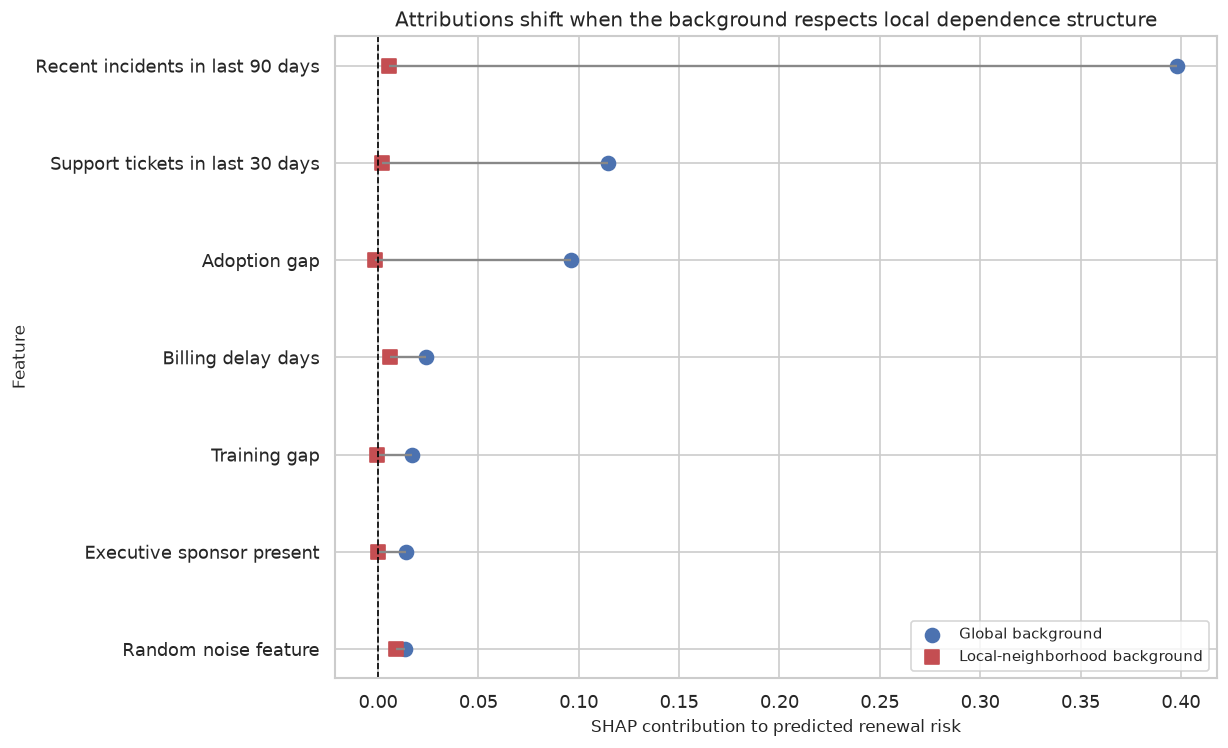

In [14]:
plot_dependence = dependence_compare.sort_values('absolute_shift', ascending=True)
fig, ax = plt.subplots(figsize=(10.4, 6.4))
y_pos = np.arange(len(plot_dependence))
ax.hlines(
    y=y_pos,
    xmin=plot_dependence['global_background_shap'],
    xmax=plot_dependence['neighborhood_background_shap'],
    color='#888888',
    linewidth=1.4,
)
ax.scatter(plot_dependence['global_background_shap'], y_pos, label='Global background', color='#4c72b0', s=70)
ax.scatter(plot_dependence['neighborhood_background_shap'], y_pos, label='Local-neighborhood background', color='#c44e52', marker='s', s=70)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_dependence['feature_label'])
ax.set_title('Attributions shift when the background respects local dependence structure')
ax.set_xlabel('SHAP contribution to predicted renewal risk')
ax.set_ylabel('Feature')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


Use the explanation as a stress test of the model narrative. In Correlated Features And Dependence Assumptions, the displayed reasons should make sense with the data-generating story and the operating decision. A report is stronger when it is honest about disagreement across explanation views.


### Discussion of Dependence Assumptions

The local-neighborhood comparison is not a replacement for a formal conditional SHAP estimator. It is a diagnostic that helps stakeholders see the issue.

If the explanation changes substantially when the background is restricted to similar accounts, the analyst should not present one SHAP chart as a universal account story. The more honest report is:

> The model's attribution pattern depends on the contrast population. Under an all-account baseline, maturity gaps dominate. Relative to similar low-maturity/high-burden accounts, the remaining drivers shift.

That is a better decision-science statement than pretending the attribution is independent of the reference population.


## 10. Monte Carlo Shapley Approximation

Exact Shapley values require all $2^p$ subsets. With many features, that becomes infeasible. A common approximation samples random feature orderings. For one permutation of features, each feature receives the marginal contribution it makes when it enters the coalition.

If $\pi$ is a random ordering and $P_j^\pi$ is the set of features before $j$ in that ordering, then

$$
\hat{\phi}_j(x)
= \frac{1}{B}\sum_{b=1}^{B}
\left[v_x(P_j^{\pi_b} \cup \{j\}) - v_x(P_j^{\pi_b})\right].
$$

As $B$ grows, the approximation should approach the exact value.


In [15]:
# Section focus: 10. Monte Carlo Shapley Approximation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def monte_carlo_shap(model, x_row, background, feature_names, n_permutations=100, seed=2050):
    """Carry out the monte carlo shap step used in the 08. SHAP Values: Intuition, Computation, and Failure Modes workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    x_row : object
        Feature row, feature matrix, or covariate value passed into the model workflow.
    background : object
        The background setting that controls the monte carlo shap calculation in this notebook.
    feature_names : object
        Column or variable name used to select information from the input table.
    n_permutations : object
        Count or size setting for the monte carlo shap calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng_local = np.random.default_rng(seed)
    feature_names = list(feature_names)
    p = len(feature_names)
    bg = background[feature_names].reset_index(drop=True).copy()
    x_values = x_row[feature_names]

    @lru_cache(maxsize=None)
    def value(subset):
        """Carry out the value step used in the 08. SHAP Values: Intuition, Computation, and Failure Modes workflow.
        
        Parameters
        ----------
        subset : object
            The subset setting that controls the value calculation in this notebook.
        
        Returns
        -------
        object
            Intermediate result produced by the value calculation and reused by later cells.
        """
        subset = tuple(sorted(subset))
        X_eval = bg.copy()
        for idx in subset:
            X_eval[feature_names[idx]] = x_values.iloc[idx]
        return float(predict_risk(model, X_eval).mean())

    phi = np.zeros(p)
    for _ in range(n_permutations):
        ordering = rng_local.permutation(p)
        current_subset = tuple()
        current_value = value(current_subset)
        for idx in ordering:
            next_subset = tuple(sorted(current_subset + (int(idx),)))
            next_value = value(next_subset)
            phi[idx] += next_value - current_value
            current_subset = next_subset
            current_value = next_value

    phi = phi / n_permutations
    return pd.DataFrame(
        {
            'feature': feature_names,
            'feature_label': [FEATURE_LABELS[f] for f in feature_names],
            'mc_shap_risk': phi,
            'abs_mc_shap_risk': np.abs(phi),
        }
    )

exact_focus = all_background_explanation[['feature', 'feature_label', 'shap_risk']].copy()
permutation_grid = [5, 10, 20, 50, 100, 200]
mc_rows = []
for n_perm in permutation_grid:
    mc = monte_carlo_shap(gbm_model, x_focus, background, FEATURES, n_permutations=n_perm, seed=2050)
    merged = mc.merge(exact_focus, on=['feature', 'feature_label'], how='left')
    merged['absolute_error'] = (merged['mc_shap_risk'] - merged['shap_risk']).abs()
    mc_rows.append(
        {
            'n_permutations': n_perm,
            'mean_absolute_error': merged['absolute_error'].mean(),
            'max_absolute_error': merged['absolute_error'].max(),
        }
    )

mc_error = pd.DataFrame(mc_rows)
smart_display(mc_error.round(5))


,n_permutations,mean_absolute_error,max_absolute_error
0,5,0.012,0.039
1,10,0.013,0.033
2,20,0.007,0.020
3,50,0.003,0.007
4,100,0.002,0.005
5,200,0.001,0.002


In Monte Carlo Shapley Approximation, pay attention to whether the explanation changes when the analyst changes plausible settings. A setting-dependent story needs a careful qualification.


,feature,feature_label,mc_shap_risk,abs_mc_shap_risk,shap_risk,absolute_error
0,adoption_gap,Adoption gap,0.094,0.094,0.096,0.002
6,random_noise_feature,Random noise feature,0.016,0.016,0.013,0.002
2,support_tickets_30d,Support tickets in last 30 days,0.113,0.113,0.114,0.002
3,recent_incidents_90d,Recent incidents in last 90 days,0.399,0.399,0.398,0.001
1,training_gap,Training gap,0.017,0.017,0.017,0.001
5,executive_sponsor,Executive sponsor present,0.014,0.014,0.014,0.000
4,billing_delay_days,Billing delay days,0.024,0.024,0.024,0.000


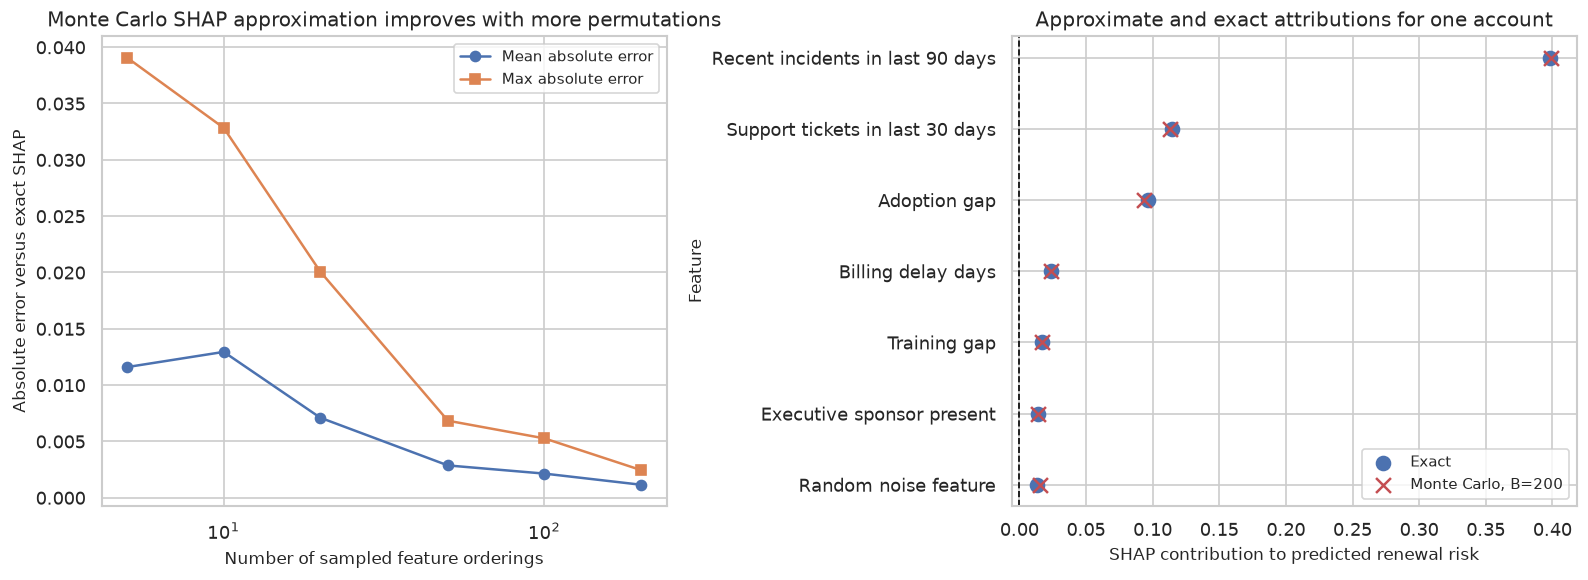

In [16]:
# Section focus: 10. Monte Carlo Shapley Approximation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

mc_200 = monte_carlo_shap(gbm_model, x_focus, background, FEATURES, n_permutations=200, seed=2050)
mc_compare = mc_200.merge(exact_focus, on=['feature', 'feature_label'], how='left')
mc_compare['absolute_error'] = (mc_compare['mc_shap_risk'] - mc_compare['shap_risk']).abs()
mc_compare = mc_compare.sort_values('absolute_error', ascending=False)
smart_display(mc_compare.round(5))

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.0))
axes[0].plot(mc_error['n_permutations'], mc_error['mean_absolute_error'], marker='o', label='Mean absolute error')
axes[0].plot(mc_error['n_permutations'], mc_error['max_absolute_error'], marker='s', label='Max absolute error')
axes[0].set_xscale('log')
axes[0].set_title('Monte Carlo SHAP approximation improves with more permutations')
axes[0].set_xlabel('Number of sampled feature orderings')
axes[0].set_ylabel('Absolute error versus exact SHAP')
axes[0].legend(loc='upper right')

plot_mc = mc_compare.sort_values('shap_risk', ascending=True)
y = np.arange(len(plot_mc))
axes[1].scatter(plot_mc['shap_risk'], y, label='Exact', color='#4c72b0', s=70)
axes[1].scatter(plot_mc['mc_shap_risk'], y, label='Monte Carlo, B=200', color='#c44e52', marker='x', s=80)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_yticks(y)
axes[1].set_yticklabels(plot_mc['feature_label'])
axes[1].set_title('Approximate and exact attributions for one account')
axes[1].set_xlabel('SHAP contribution to predicted renewal risk')
axes[1].set_ylabel('Feature')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


The explanation result should be compared with the decision story. In Monte Carlo Shapley Approximation, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. When the explanation is thin, the final recommendation becomes harder to justify.


### Discussion of Monte Carlo Approximation

The approximation is useful because exact enumeration scales exponentially in the number of features. But approximation adds another source of uncertainty. In a production setting, the report should include enough repetitions for stable explanations, or at least note when explanations are approximate.

This connects to a broader lesson from the AI-for-causal-inference course: local explanation systems are computational workflows. They can be brittle, stochastic, and sensitive to modeling choices. Treat the explanation as an object to validate, not as an oracle.


## 11. Failure Modes In Decision Use

SHAP is powerful, but the most common mistakes are conceptual rather than computational.

| Failure mode | What goes wrong | Practical guardrail |
|---|---|---|
| Causal overreading | A positive attribution is treated as an intervention effect | Say “the model used this feature,” not “changing this feature will cause the outcome to change” |
| Hidden baseline | Stakeholders see bars but not the reference population | Always report the background data and baseline value |
| Correlated-feature credit splitting | Related features divide or transfer attribution | Show grouped constructs or multiple dependence assumptions |
| Output-scale confusion | Probability-scale and log-odds-scale attributions are mixed | State the model output being explained |
| Local-to-global leap | A single account explanation becomes a global rule | Pair local explanations with global summaries and stability checks |
| Proxy laundering | Sensitive or fragile proxies look mathematically important | Audit proxy features and downstream use constraints |
| Approximation noise | Monte Carlo or sampling choices change ranks | Use enough samples and report stability |

A good SHAP chart is not the end of the analysis. It is an invitation to ask whether the model's behavior is acceptable for the decision being made.


In [17]:
# Section focus: 11. Failure Modes In Decision Use.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

reporting_checklist = pd.DataFrame(
    [
        {
            'reporting_item': 'Model and output scale',
            'question_to_answer': 'Which fitted model and which output were explained?',
            'example_for_this_notebook': 'Gradient boosting predicted renewal-risk probability',
        },
        {
            'reporting_item': 'Baseline/background',
            'question_to_answer': 'What reference population defines zero contribution?',
            'example_for_this_notebook': '90 sampled training accounts, plus sensitivity baselines',
        },
        {
            'reporting_item': 'Local explanation',
            'question_to_answer': 'Which features moved this account above or below baseline?',
            'example_for_this_notebook': 'Waterfall-style bars for high- and low-risk accounts',
        },
        {
            'reporting_item': 'Global pattern',
            'question_to_answer': 'Which features contribute most across many accounts?',
            'example_for_this_notebook': 'Mean absolute SHAP and beeswarm-style plot',
        },
        {
            'reporting_item': 'Dependence sensitivity',
            'question_to_answer': 'Do attributions change under a more local background?',
            'example_for_this_notebook': 'Global-background versus local-neighborhood comparison',
        },
        {
            'reporting_item': 'Causal warning',
            'question_to_answer': 'Is the explanation being used as an intervention claim?',
            'example_for_this_notebook': 'Explicit noncausal wording in stakeholder interpretation',
        },
    ]
)
smart_display(reporting_checklist)


,reporting_item,question_to_answer,example_for_this_notebook
0,Model and output scale,Which fitted model and which output were explained?,Gradient boosting predicted renewal-risk probability
1,Baseline/background,What reference population defines zero contribution?,"90 sampled training accounts, plus sensitivity baselines"
2,Local explanation,Which features moved this account above or below baseline?,Waterfall-style bars for high- and low-risk accounts
3,Global pattern,Which features contribute most across many accounts?,Mean absolute SHAP and beeswarm-style plot
4,Dependence sensitivity,Do attributions change under a more local background?,Global-background versus local-neighborhood comparison
5,Causal warning,Is the explanation being used as an intervention claim?,Explicit noncausal wording in stakeholder interpretation


For Failure Modes In Decision Use, the explanation earns trust through stability and reviewability, not through a polished chart alone.


## 12. Key Takeaways

- SHAP values decompose a chosen model output into a baseline plus feature attributions.
- The baseline/background distribution is part of the explanation, not a technical footnote.
- Exact Shapley computation requires all feature subsets, so approximation or model-specific algorithms are often needed.
- Local SHAP values explain one prediction; global SHAP summaries aggregate many local explanations.
- Mean absolute SHAP and permutation importance are related but answer different questions.
- Correlated features make attribution more delicate because interventional and dependence-aware explanations answer different questions.
- A positive SHAP value is not a causal effect, not a recommendation, and not a guarantee of actionability.
- Professional SHAP reporting should include model, output scale, background data, approximation details, stability checks, and causal caveats.


## References

- Aas, K., Jullum, M., & Løland, A. (2021). *Explaining individual predictions when features are dependent: More accurate approximations to Shapley values*. *Artificial Intelligence, 298*, 103502. [https://doi.org/10.1016/j.artint.2021.103502](https://doi.org/10.1016/j.artint.2021.103502)
- Lundberg, S. M., & Lee, S.-I. (2017). *A unified approach to interpreting model predictions*. arXiv. [https://doi.org/10.48550/arXiv.1705.07874](https://doi.org/10.48550/arXiv.1705.07874)
- Lundberg, S. M., Erion, G., Chen, H., et al. (2020). *From local explanations to global understanding with explainable AI for trees*. *Nature Machine Intelligence, 2*(1), 56-67. [https://doi.org/10.1038/s42256-019-0138-9](https://doi.org/10.1038/s42256-019-0138-9)
- Mitchell, R., Frank, E., & Holmes, G. (2022). *GPUTreeShap: massively parallel exact calculation of SHAP scores for tree ensembles*. *PeerJ Computer Science, 8*, e880. [https://doi.org/10.7717/peerj-cs.880](https://doi.org/10.7717/peerj-cs.880)
- Sellereite, N., & Jullum, M. (2019). *shapr: An R-package for explaining machine learning models with dependence-aware Shapley values*. *Journal of Open Source Software, 5*(46), 2027. [https://doi.org/10.21105/joss.02027](https://doi.org/10.21105/joss.02027)
